# Dataset description :

This notebook presents an end-to-end regression workflow using the target variable `loan_amount`.

We will cover:

1. **Exploratory Data Analysis (EDA)** with visualizations  
2. **Data preprocessing**
   - Missing values handling
   - Duplicate removal
   - Outlier detection and handling
   - Data consistency correction
   - Format standardization
3. **Data transformation**
   - Categorical encoding
   - Feature scaling / normalization
   - Feature transformation
   - Feature engineering
   - Feature selection
4. **Training and comparing multiple regression models**
5. **Evaluation using several metrics and validation techniques**
6. **Inference function** for predicting loan ammount from user inputs

> Dataset file used: `loan_approval.csv`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OrdinalEncoder
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 1. Loading the dataset

In [2]:
data_path = "loan_approval.csv"
target_col = "loan_amount"
df = pd.read_csv(data_path)
print("Using dataset:", data_path)
print("Shape:", df.shape)

display(df.head())

Using dataset: loan_approval.csv
Shape: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

binary_cols = [
    col for col in df.columns
    if df[col].nunique() == 2 and set(df[col].dropna().unique()) <= {0, 1}
]

numeric_cols = [col for col in numeric_cols if col not in binary_cols]
categorical_cols = categorical_cols + binary_cols

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical columns: ['education', 'self_employed', 'loan_status']


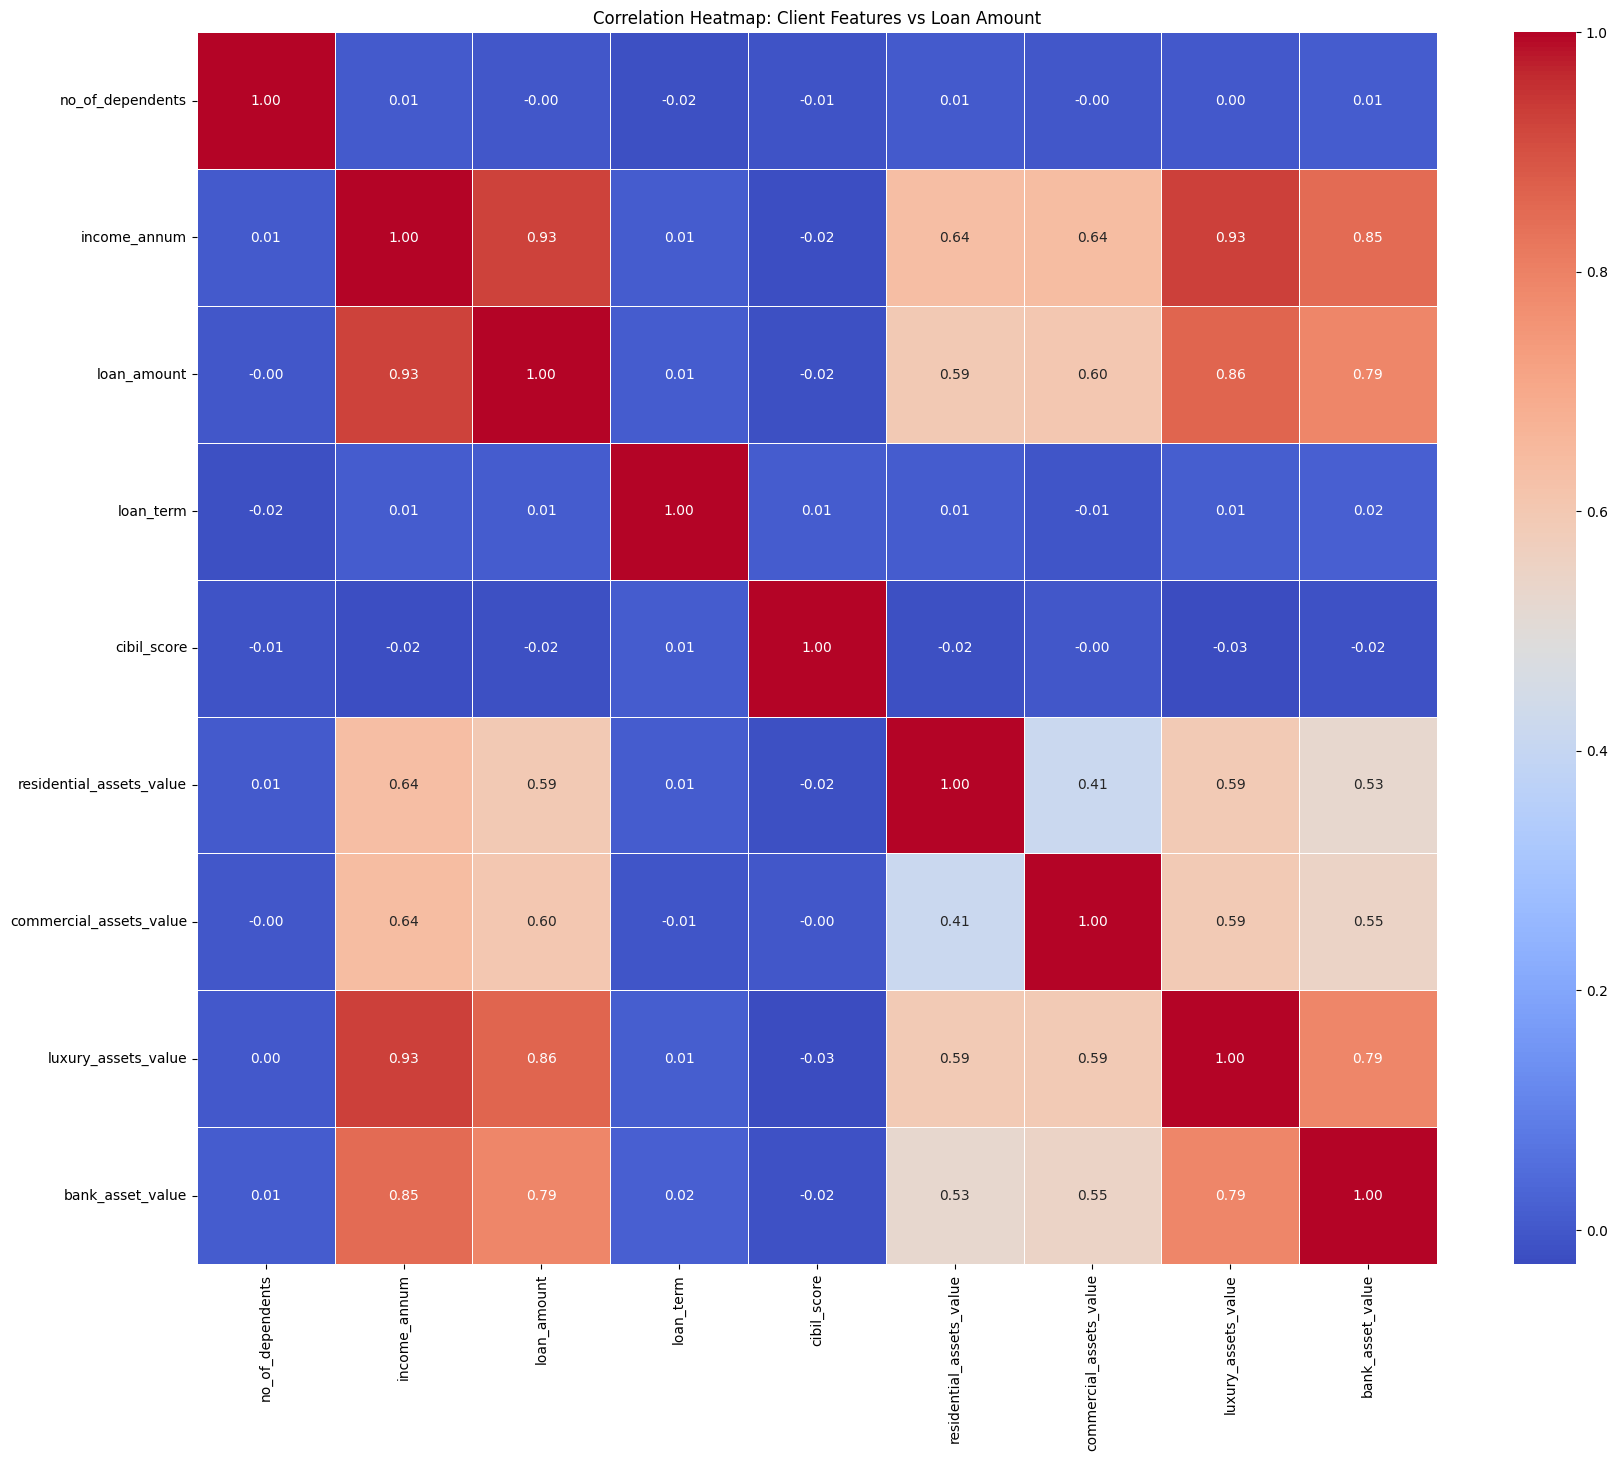

In [4]:
# 1. Calculate correlation matrix using the existing columns
correlation_matrix = df[numeric_cols].corr()

# 2. Create the Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Client Features vs Loan Amount')
plt.show()

In [5]:
df_clean = df.copy()
# Missing values handling check
missing_summary = df_clean.isna().sum().to_frame("missing_count")
display(missing_summary)

print("Total missing values:", df_clean.isna().sum().sum())

,missing_count
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


Total missing values: 0


In [6]:
# Remove duplicates
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
duplicates_after = df_clean.duplicated().sum()

print("Duplicates before removal:", duplicates_before)
print("Duplicates after removal:", duplicates_after)
print("New shape:", df_clean.shape)

Duplicates before removal: 0
Duplicates after removal: 0
New shape: (4269, 12)


## Train / Test Split

We split the dataset before applying transformations to avoid data leakage

In [7]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

### Outlier Detection & Handling, Skewedness, Encoding & Scaling.
We detect potential outliers with the **IQR rule** on numerical features. Then we will cap the outliers, do log transformation on the skewed features then finally we will encode categorical data and scale some of the numerical ones.

In [8]:
numeric_cols.remove(target_col)

def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        rows.append({
            "feature": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "lower_bound": round(lower, 2),
            "upper_bound": round(upper, 2),
            "outlier_count": int(count)
        })
    return pd.DataFrame(rows)

display(iqr_outlier_summary(df_clean, numeric_cols))

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,no_of_dependents,1.0,4.0,3.0,-3.5,8.5,0
1,income_annum,2700000.0,7500000.0,4800000.0,-4500000.0,14700000.0,0
2,loan_term,6.0,16.0,10.0,-9.0,31.0,0
3,cibil_score,453.0,748.0,295.0,10.5,1190.5,0
4,residential_assets_value,2200000.0,11300000.0,9100000.0,-11450000.0,24950000.0,52
5,commercial_assets_value,1300000.0,7600000.0,6300000.0,-8150000.0,17050000.0,37
6,luxury_assets_value,7500000.0,21700000.0,14200000.0,-13800000.0,43000000.0,0
7,bank_asset_value,2300000.0,7100000.0,4800000.0,-4900000.0,14300000.0,5


In [9]:
# cap_cols = ["bmi", "income", "diastolic_bp", "ldl", "hba1c", "days_hospitalized_last_3yrs"]

# n = len(cap_cols)

# cols = 2
# rows = math.ceil(n / cols)

# plt.figure(figsize=(cols * 5, rows * 4))

# for i, col in enumerate(cap_cols, 1):
#     plt.subplot(rows, cols, i)
    
#     plt.boxplot(
#         df_clean[col].dropna(),
#         vert=True,
#         patch_artist=True,
#         boxprops=dict(facecolor='lightblue', color='black'),
#         capprops=dict(color='black'),
#         whiskerprops=dict(color='black'),
#         flierprops=dict(markeredgecolor='black', marker='o')
#     )
    
#     plt.title(f'Boxplot of {col}')
#     plt.xlabel(col)

# plt.tight_layout()
# plt.show()

In [10]:
# for col in cap_cols:
#     q1 = X_train[col].quantile(0.25)
#     q3 = X_train[col].quantile(0.75)
#     iqr = q3 - q1

#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     X_train[col] = X_train[col].clip(lower, upper)
#     X_test[col] = X_test[col].clip(lower, upper)


In [11]:
skew_vals = X_train[numeric_cols].skew().sort_values(ascending=False)
print("Skewness values for numerical features:")
print(skew_vals)

Skewness values for numerical features:
commercial_assets_value     0.997638
residential_assets_value    0.987596
bank_asset_value            0.567157
luxury_assets_value         0.327600
loan_term                   0.013694
cibil_score                -0.003219
income_annum               -0.006172
no_of_dependents           -0.013436
dtype: float64


All features that have a higher skew then `1` will be transformed with logarithmic scale

In [12]:
skewed_cols = skew_vals[skew_vals.abs() > 1].index.tolist()

X_train[skewed_cols] = np.log1p(X_train[skewed_cols])
X_test[skewed_cols] = np.log1p(X_test[skewed_cols])

In [13]:
num_imputer = SimpleImputer(strategy="median")

X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

In [14]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

## a) Ordinal Encoding

In [15]:
# X_train_pre_encoding = X_train.copy()

# ordinal_cols = ['network_tier', 'education', 'alcohol_freq', 'plan_type']

# ordinal_orders = [
#     ['Bronze', 'Silver', 'Gold', 'Platinum'],
#     ['No HS', 'HS', 'Some College', 'Bachelors', 'Masters', 'Doctorate'],
#     ['Non-drinker', 'Occasional', 'Weekly', 'Daily'],
#     ['HMO', 'POS', 'PPO', 'EPO']
# ]

# ordinalEncoder = OrdinalEncoder(categories=ordinal_orders)

# X_train[ordinal_cols] = ordinalEncoder.fit_transform(X_train[ordinal_cols])
# X_test[ordinal_cols] = ordinalEncoder.transform(X_test[ordinal_cols])

## b) One-Hot Encoding

In [16]:
# ohe_cols = [
#     'sex', 'smoker', 'urban_rural',
#     'region', 'marital_status', 'employment_status'
# ]


# ohe_cols = [col for col in ohe_cols if col in X_train.columns]

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)


X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print("Shape after encoding:", X_train.shape)

Shape after encoding: (3415, 11)


## Scaling

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Final training shape:", X_train.shape)
print("Final test shape:", X_test.shape)

Final training shape: (3415, 11)
Final test shape: (854, 11)


## 6. Build and Compare Multiple Regression Models

We will compare a broad set of regression algorithms:

- Linear-family models
    - Linear Regression
    - Ridge

- Nonlinear
    - Polynomial Regression

- Tree-based and ensemble models
    - Random Forest Regressor


In [18]:
# Initialize models
linear_model = LinearRegression()

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_scaled)
X_poly_test = poly.transform(X_test_scaled)


poly_model = LinearRegression()

#Ridge regression
ridge_model = Ridge()

#Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_features='sqrt', random_state=42)

#XGBoost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train models
linear_model.fit(X_train_scaled, y_train)
poly_model.fit(X_poly_train, y_train)
ridge_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [19]:
# model evaluation

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

# polynomilal regression
X_poly_test = poly.fit_transform(X_test_scaled)
y_pred_poly = poly_model.predict(X_poly_test)

# ridge regression
y_pred_ridge = ridge_model.predict(X_test_scaled)

# random forest
y_pred_rf = rf_model.predict(X_test_scaled)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f'{model_name}:')
    print(f'Mean Squared Error (MSE): {mse:.2f}')
    print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
    print(f'R-squared (R2): {r2:.2f}')
    print('---')

evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_poly, "Polynomial Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")
evaluate_model(y_test, y_pred_xgb, "XGBoost Regression")

Linear Regression:
Mean Squared Error (MSE): 11448076533981.60
Root Mean Squared Error (RMSE): 3383500.63
R-squared (R2): 0.86
---
Polynomial Regression:
Mean Squared Error (MSE): 11476535102559.24
Root Mean Squared Error (RMSE): 3387703.51
R-squared (R2): 0.86
---
Ridge Regression:
Mean Squared Error (MSE): 11446881931397.77
Root Mean Squared Error (RMSE): 3383324.09
R-squared (R2): 0.86
---
Random Forest Regression:
Mean Squared Error (MSE): 11857179345433.26
Root Mean Squared Error (RMSE): 3443425.52
R-squared (R2): 0.85
---
XGBoost Regression:
Mean Squared Error (MSE): 12246289743872.00
Root Mean Squared Error (RMSE): 3499469.92
R-squared (R2): 0.85
---


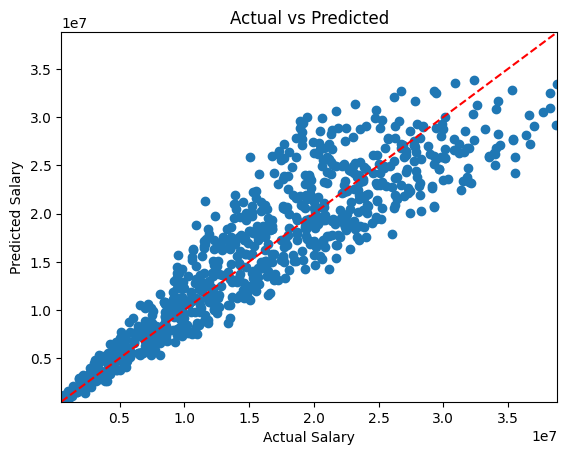

In [20]:
plt.scatter(y_test, y_pred_xgb)

lims = [
    min(min(y_test), min(y_pred_xgb)),
    max(max(y_test), max(y_pred_xgb))
]

plt.plot(lims, lims, 'r--')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

## 7. Importance 

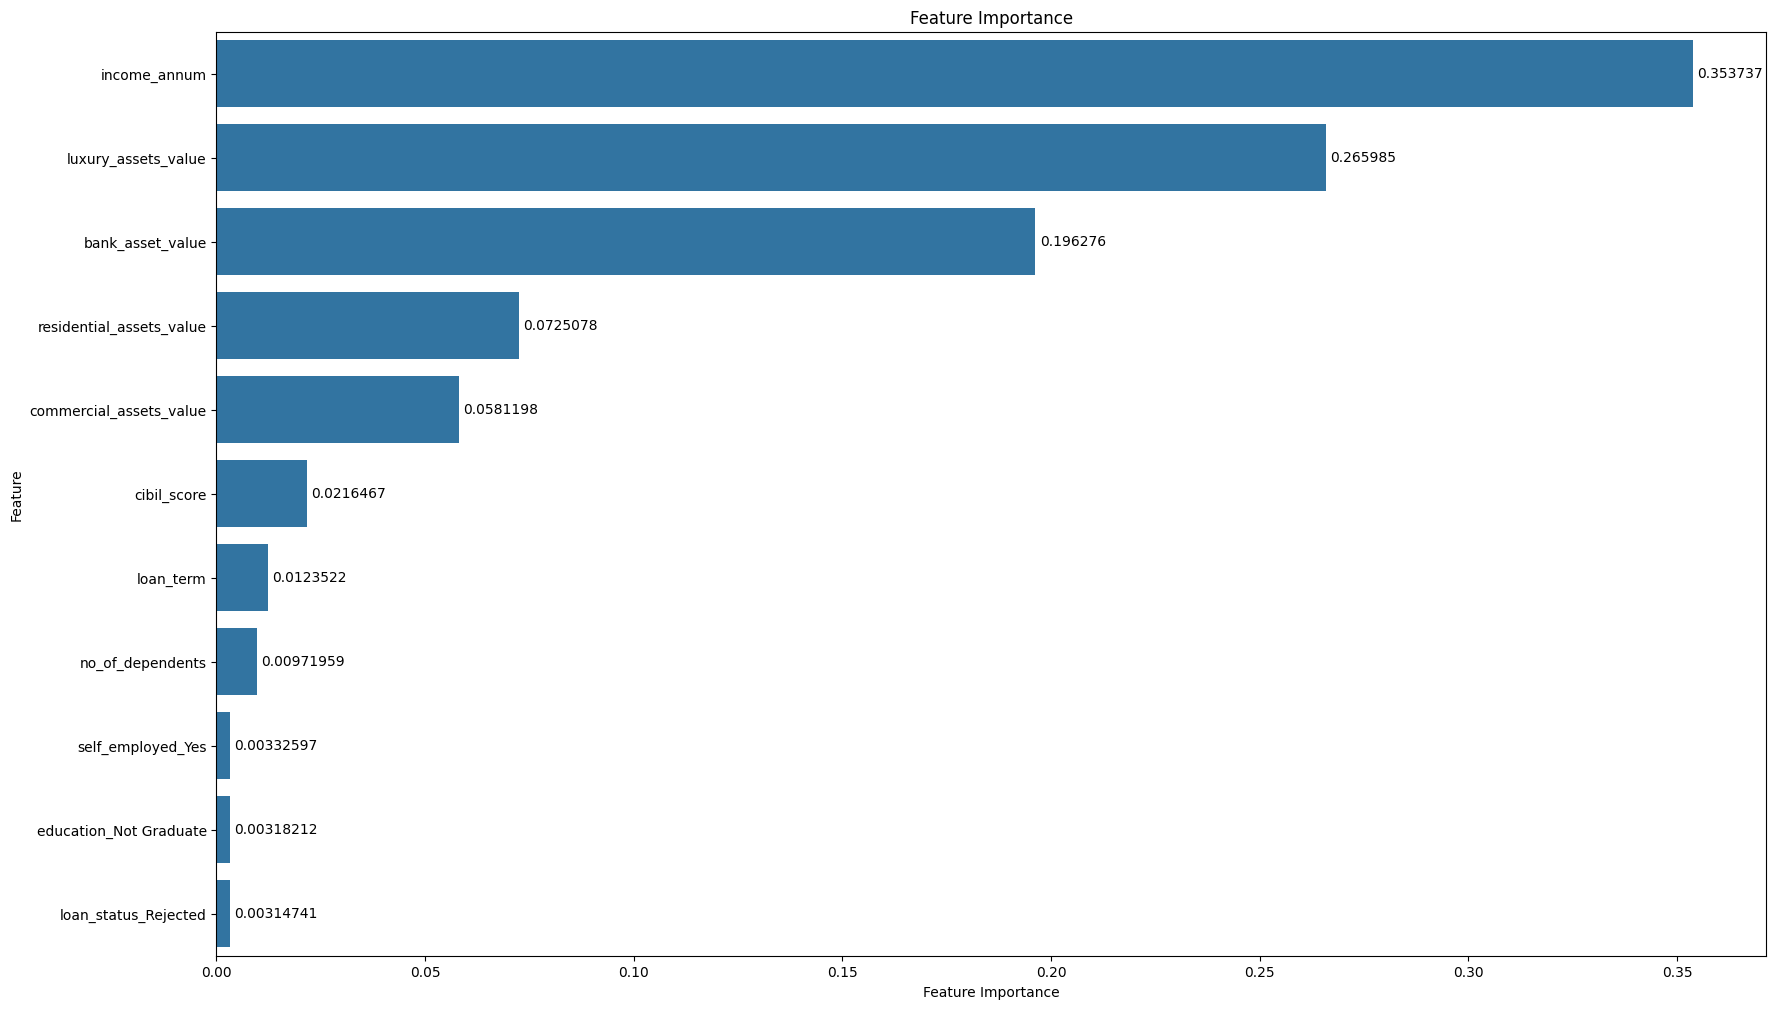

In [21]:
model = rf_model

feature_importances_dt = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for feature importances
df_feature_importances_dt = pd.DataFrame({'feature': feature_names, 'importance': feature_importances_dt})
df_feature_importances_dt = df_feature_importances_dt.sort_values('importance', ascending=False)

# Plot feature importances for Decision Tree
plt.figure(figsize=(20, 12))
ax = sns.barplot(x='importance', y='feature', data=df_feature_importances_dt)
plt.title('Feature Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()